# 03 — PSI comparison: Strict vs Variable 1nt

This notebook compares PSI values between the strict and variable 1nt boundary modes
for RI, A3, and A5 splicing events.

For each event type we look at three populations:
- **Shared events** — present in both modes; do PSI values change?
- **Variable-only events** — detected in variable but not in strict (Q1 + Q2)
- **Novel-transcript events** — non-ENSMUSG coordinate-based IDs (Q3)

Samples: KM1–KM3 = CT8 | KM4–KM6 = CT20 | KM7–KM9 = PerKO

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded!")

Libraries loaded!


In [27]:
# -- Helper functions --

def style_table(df, caption=""):
    """Apply consistent blue-header styling to a DataFrame for display."""
    styled = df.style\
        .set_properties(**{
            "font-size": "12px",
            "font-weight": "bold",
            "border": "1px solid #ddd",
            "padding": "6px 12px",
            "text-align": "center"
        })\
        .set_table_styles([
            {"selector": "th", "props": [
                ("background-color", "#2196F3"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("padding", "6px 12px"),
                ("text-align", "center")
            ]},
            {"selector": "tr:nth-child(even)", "props": [
                ("background-color", "#f2f2f2")
            ]},
        ])\
        .hide(axis="index")
    if caption:
        styled = styled.set_caption(caption)
    return styled


def export_table_png(df, filepath, title=""):
    col_widths = []
    for col in df.columns:
        max_content = max(
            len(str(col)),
            df[col].astype(str).map(len).max()
        )
        col_widths.append(max_content)

    fig_width = max(sum(col_widths) * 0.15, 6)
    fig_height = len(df) * 0.6 + 0.8

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.6)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("#2196F3")
            cell.set_text_props(color="white", fontweight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#f2f2f2")
        else:
            cell.set_facecolor("white")
        cell.set_edgecolor("#dddddd")
    if title:
        ax.set_title(title, fontsize=12, y=0.88)
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved to {filepath}")


print("Helpers loaded!")

Helpers loaded!


In [28]:
# -- Paths --
BASE = "/Users/gricey/Desktop/Internship/data"

SAMPLES = ["KM1", "KM2", "KM3", "KM4", "KM5", "KM6", "KM7", "KM8", "KM9"]
CONDITIONS = {
    "CT8":   ["KM1", "KM2", "KM3"],
    "CT20":  ["KM4", "KM5", "KM6"],
    "PerKO": ["KM7", "KM8", "KM9"],
}

EVENT_TYPES = ["RI", "A3", "A5"]

In [ ]:
# -- Load PSI files for all event types --
# The variable file has a duplicate header row and some coordinate-based IDs mixed in. The load_psi() function handles both of those issues.
def load_psi(path):
    """Load a SUPPA PSI file, handling duplicate headers from variable mode."""
    df = pd.read_csv(path, sep="\t", index_col=0)
    # Drop any rows where the index looks like a header (e.g. 'KM1')
    df = df[~df.index.str.startswith("KM")]
    df = df.apply(pd.to_numeric, errors="coerce")
    return df


psi = {}
for event in EVENT_TYPES:
    psi[("strict", event)]   = load_psi(f"{BASE}/output_strict/psi/{event}.psi")
    psi[("var1",   event)]   = load_psi(f"{BASE}/output_variable_1nt/psi/{event}.psi")
    print(f"{event}: strict={len(psi[('strict', event)])} events, "
          f"var1={len(psi[('var1', event)])} events")

RI: strict=5315 events, var1=17336 events
A3: strict=11163 events, var1=22931 events
A5: strict=9629 events, var1=19455 events


## Section 1 — Population counts

For each event type, split events into:
- **Shared** — event ID present in both strict and variable
- **Variable-only** — only in variable (ENSMUSG gene ID)
- **Novel** — only in variable, non-ENSMUSG coordinate-based ID

In [ ]:
# -- Section 1: Population counts (gene-level matching) --
pop_rows = []

for event in EVENT_TYPES:
    strict_df = psi[("strict", event)]
    var1_df   = psi[("var1",   event)]

    # Gene IDs present in each mode
    strict_genes = set(idx.split(";")[0] for idx in strict_df.index
                       if idx.startswith("ENSMUSG"))
    var1_genes   = set(idx.split(";")[0] for idx in var1_df.index
                       if idx.startswith("ENSMUSG"))

    shared_genes  = strict_genes & var1_genes
    varonly_genes = var1_genes - strict_genes

    # Event counts
    strict_events  = [idx for idx in strict_df.index if idx.startswith("ENSMUSG")]
    varonly_events = [idx for idx in var1_df.index
                      if idx.startswith("ENSMUSG")
                      and idx.split(";")[0] not in strict_genes]
    novel_events   = [idx for idx in var1_df.index if not idx.startswith("ENSMUSG")]

    pop_rows.append({
        "Event":                         event,
        "Strict events":                 len(strict_events),
        "Variable events (ENSMUSG)":     len(var1_df[var1_df.index.str.startswith("ENSMUSG")]),
        "Shared genes (both s,v)":     len(shared_genes),
        "Variable-only genes":           len(varonly_genes),
        "Variable-only events":          len(varonly_events),
        "Novel-ID events":               len(novel_events),
    })

df_pop = pd.DataFrame(pop_rows)
display(style_table(df_pop, caption="PSI-level event populations: Strict vs Variable 1nt"))
export_table_png(df_pop, "../../figures/plots/table_psi_populations.png",
                 title="PSI-level event populations: Strict vs Variable 1nt")

Event,Strict events,Variable events (ENSMUSG),Shared genes (both modes),Variable-only genes,Variable-only events,Novel-ID events
RI,5315,17335,3163,4404,7978,1
A3,11163,22931,6684,3423,5282,0
A5,9629,19455,5905,3097,4897,0


Saved to ../../figures/plots/table_psi_populations.png


## Section 2 — PSI shift for shared events

For events present in **both** modes, compute the mean absolute PSI difference
across all samples: `|PSI_variable - PSI_strict|`.

This tells us whether relaxing the boundary changes the quantification
for events that both modes detect.

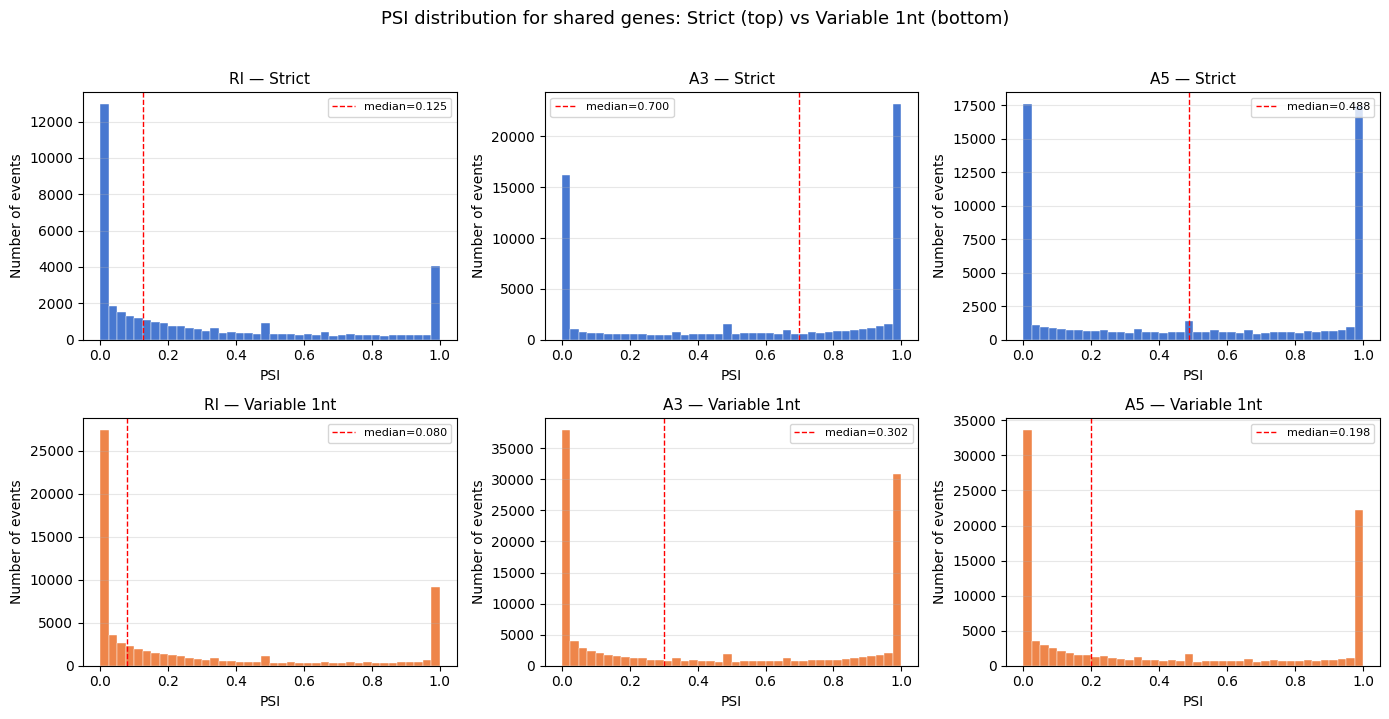

Saved!


In [37]:
# Section 2 — PSI distribution for shared genes: strict vs variable
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for i, event in enumerate(EVENT_TYPES):
    strict_df = psi[("strict", event)]
    var1_df   = psi[("var1",   event)]

    strict_genes = set(idx.split(";")[0] for idx in strict_df.index
                       if idx.startswith("ENSMUSG"))
    var1_genes   = set(idx.split(";")[0] for idx in var1_df.index
                       if idx.startswith("ENSMUSG"))
    shared_genes = strict_genes & var1_genes

    strict_vals = strict_df[
        strict_df.index.map(lambda x: x.split(";")[0] if x.startswith("ENSMUSG") else "")
        .isin(shared_genes)
    ].values.flatten()
    strict_vals = strict_vals[~np.isnan(strict_vals)]

    var1_vals = var1_df[
        var1_df.index.map(lambda x: x.split(";")[0] if x.startswith("ENSMUSG") else "")
        .isin(shared_genes)
    ].values.flatten()
    var1_vals = var1_vals[~np.isnan(var1_vals)]

    # Top row: strict
    ax_top = axes[0, i]
    ax_top.hist(strict_vals, bins=40, color=muted[0], edgecolor="white", linewidth=0.3)
    ax_top.set_title(f"{event} — Strict", fontsize=11)
    ax_top.set_ylabel("Number of events")
    ax_top.set_xlabel("PSI")
    ax_top.axvline(np.median(strict_vals), color="red", linestyle="--",
                   linewidth=1, label=f"median={np.median(strict_vals):.3f}")
    ax_top.legend(fontsize=8)
    ax_top.grid(axis="y", alpha=0.3)

    # Bottom row: variable
    ax_bot = axes[1, i]
    ax_bot.hist(var1_vals, bins=40, color=muted[1], edgecolor="white", linewidth=0.3)
    ax_bot.set_title(f"{event} — Variable 1nt", fontsize=11)
    ax_bot.set_ylabel("Number of events")
    ax_bot.set_xlabel("PSI")
    ax_bot.axvline(np.median(var1_vals), color="red", linestyle="--",
                   linewidth=1, label=f"median={np.median(var1_vals):.3f}")
    ax_bot.legend(fontsize=8)
    ax_bot.grid(axis="y", alpha=0.3)

plt.suptitle("PSI distribution for shared genes: Strict (top) vs Variable 1nt (bottom)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../../figures/plots/hist_psi_shared_genes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

In [32]:
# Section 2 — summary table for PSI shift
df_shift = pd.DataFrame(shift_summary)
display(style_table(df_shift, caption="PSI summary for shared genes"))
export_table_png(df_shift, "../../figures/plots/table_psi_shared_genes.png",
                 title="PSI summary for shared genes")

Event,Shared genes,Strict PSI events,Variable PSI events,Strict median PSI,Variable median PSI
RI,3163,37795,68057,0.125,0.080
A3,6684,67534,116655,0.700,0.302
A5,5905,60633,98246,0.488,0.198


Saved to ../../figures/plots/table_psi_shared_genes.png


## Section 3 — PSI distribution for variable-only events

For events **only detected in variable mode**, look at their mean PSI per condition.
If they have non-zero PSI, they are biologically expressed and missed by strict.

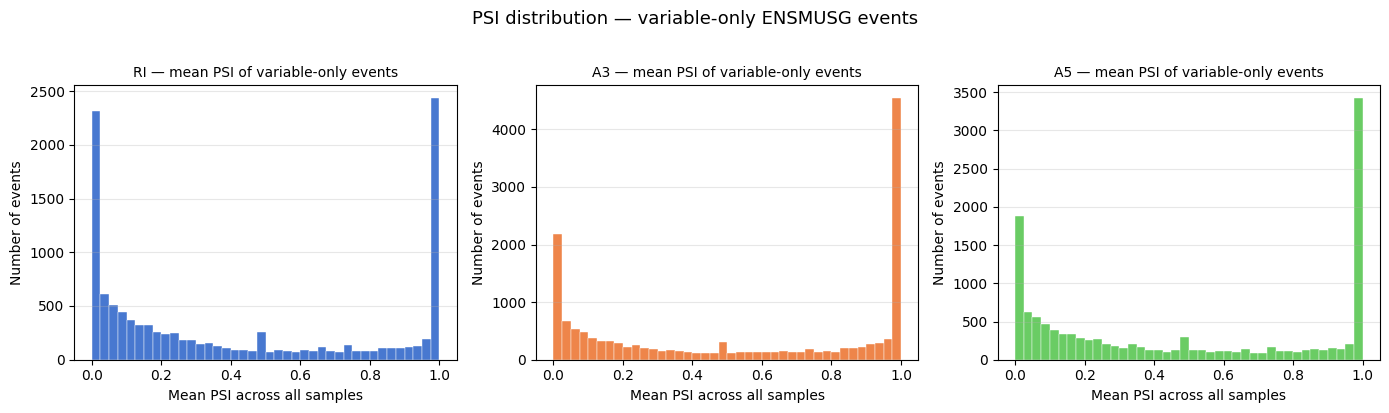

Saved!


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

varonly_summary = []

for i, event in enumerate(EVENT_TYPES):
    strict_ids = set(psi[("strict", event)].index)
    var1_df    = psi[("var1",   event)]

    var_only_ids = [idx for idx in var1_df.index
                    if idx not in strict_ids and idx.startswith("ENSMUSG")]
    var_only_df  = var1_df.loc[var_only_ids]

    # Mean PSI per event across all samples (ignore NaN)
    mean_psi = var_only_df.mean(axis=1).dropna()

    # How many have at least some expression (mean PSI > 0)?
    n_expressed = int((mean_psi > 0).sum())
    n_all_nan   = int(var_only_df.isna().all(axis=1).sum())

    varonly_summary.append({
        "Event": event,
        "Variable-only events (ENSMUSG)": len(var_only_ids),
        "All-NaN (no TPM support)": n_all_nan,
        "Mean PSI > 0 (expressed)": n_expressed,
        "Mean PSI = 0 (not used)": int((mean_psi == 0).sum()),
    })

    ax = axes[i]
    ax.hist(mean_psi[mean_psi > 0], bins=40, color=muted[i], edgecolor="white", linewidth=0.3)
    ax.set_title(f"{event} — mean PSI of variable-only events", fontsize=10)
    ax.set_xlabel("Mean PSI across all samples")
    ax.set_ylabel("Number of events")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("PSI distribution — variable-only ENSMUSG events", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../../figures/plots/hist_psi_varonly.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

In [34]:
# Summary table for variable-only events
df_varonly = pd.DataFrame(varonly_summary)
display(style_table(df_varonly, caption="Variable-only events: expression status"))
export_table_png(df_varonly, "../../figures/plots/table_psi_varonly.png",
                 title="Variable-only events: expression status")

Event,Variable-only events (ENSMUSG),All-NaN (no TPM support),Mean PSI > 0 (expressed),Mean PSI = 0 (not used)
RI,17335,2384,11389,3562
A3,22931,3966,15222,3743
A5,19455,3040,12916,3499


Saved to ../../figures/plots/table_psi_varonly.png


## Section 4 — Per-condition PSI: shared vs variable-only

For each condition (CT8, CT20, PerKO), compare the mean PSI of:
- shared events (detected in both modes)
- variable-only events (new in variable)

This shows whether the newly detected events have comparable expression levels
or are systematically lower (weaker events missed by strict).

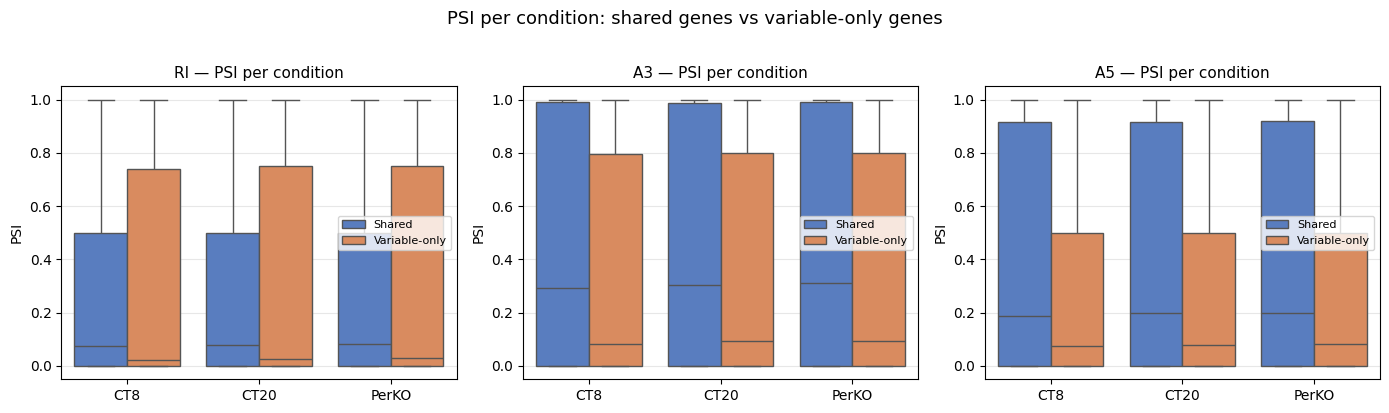

Saved!


In [35]:
# Section 4 — PSI per condition: shared genes vs variable-only genes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, event in enumerate(EVENT_TYPES):
    strict_df = psi[("strict", event)]
    var1_df   = psi[("var1",   event)]

    strict_genes  = set(idx.split(";")[0] for idx in strict_df.index
                        if idx.startswith("ENSMUSG"))
    var1_genes    = set(idx.split(";")[0] for idx in var1_df.index
                        if idx.startswith("ENSMUSG"))
    shared_genes  = strict_genes & var1_genes
    varonly_genes = var1_genes - strict_genes

    rows = []
    for cond, samples in CONDITIONS.items():
        # Shared: use variable PSI for shared genes (same genes, more events)
        shared_psi = var1_df[
            var1_df.index.map(lambda x: x.split(";")[0] if x.startswith("ENSMUSG") else "")
            .isin(shared_genes)
        ][samples].values.flatten()

        varonly_psi = var1_df[
            var1_df.index.map(lambda x: x.split(";")[0] if x.startswith("ENSMUSG") else "")
            .isin(varonly_genes)
        ][samples].values.flatten()

        for v in shared_psi[~np.isnan(shared_psi)]:
            rows.append({"Condition": cond, "Population": "Shared", "PSI": v})
        for v in varonly_psi[~np.isnan(varonly_psi)]:
            rows.append({"Condition": cond, "Population": "Variable-only", "PSI": v})

    df_plot = pd.DataFrame(rows)

    ax = axes[i]
    sns.boxplot(
        data=df_plot, x="Condition", y="PSI", hue="Population",
        palette={"Shared": muted[0], "Variable-only": muted[1]},
        showfliers=False, ax=ax
    )
    ax.set_title(f"{event} — PSI per condition", fontsize=11)
    ax.set_ylabel("PSI")
    ax.set_xlabel("")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("PSI per condition: shared genes vs variable-only genes",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../../figures/plots/boxplot_psi_by_condition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

In [36]:
strict_ri = psi[("strict", "RI")]
var1_ri   = psi[("var1",   "RI")]

print("Strict index sample:")
print(strict_ri.index[:5].tolist())
print()
print("Variable index sample:")
print(var1_ri.index[:5].tolist())
print()
# Check if a known strict event appears in variable
test = "ENSMUSG00000000028;RI:16:18629231-18630055:-"
print(f"Test ID in strict index: {test in strict_ri.index}")
print(f"Test ID in var1 index:   {test in var1_ri.index}")

Strict index sample:
['ENSMUSG00000000031;RI:7:142129268:142129851-142129940:142130267:-', 'ENSMUSG00000000031;RI:7:142129940:142130067-142130146:142130267:-', 'ENSMUSG00000000085;RI:4:120386331:120386445-120386951:120387381:+', 'ENSMUSG00000000088;RI:9:57436239:57436355-57437524:57437645:+', 'ENSMUSG00000000131;RI:7:125706243:125706404-125707624:125707795:-']

Variable index sample:
['12:25143000;RI:12:25144575-25145662:-', 'ENSMUSG00000000028;RI:16:18629231-18630055:-', 'ENSMUSG00000000028;RI:16:18630114-18630265:-', 'ENSMUSG00000000028;RI:16:18630459-18630554:-', 'ENSMUSG00000000031;RI:7:142129430-142131275:-']

Test ID in strict index: False
Test ID in var1 index:   True
